# Read Counts

In [2]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Initial - QC

In [3]:
# raw and trimmed reads were written via script - found in 0QC_trimming-all
    # combining and pivoting to make easier to read

In [4]:
setwd('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/')
reads<-read.csv('reads.csv')
sampleids<-read.table('sampleids.txt', sep = "",header = FALSE)
sampleids$sampleid <- sampleids$V1
sampleids$V1 <- NULL

In [5]:
# make sure raw read counts R1 and R2 match
raw_read_match<-reads %>%
    filter(step == 'raw') %>%
    # add base sampleid to match by
    mutate(sampleid = str_remove(sample, "_R[12]_001.fastq")) %>%
    group_by(sampleid) %>%
    # make sure there are 2 seqs per sameplid and that there is only 1 distinct value (meaning they have the same read count)
    mutate(reads_match = case_when(
      n() == 2 & n_distinct(read_count) == 1 ~ TRUE,
      TRUE ~ FALSE
  )) %>%
  ungroup()

# make sure there are no falses
raw_read_match %>%
    filter(reads_match == FALSE)

# perfect they all match 

sample,read_count,step,sampleid,reads_match
<chr>,<int>,<chr>,<chr>,<lgl>


In [6]:
# check sample numbers match 
nsample<-nrow(sampleids) # 225 samples
nsample*2

nrow(reads%>%filter(step=='raw'))
# extra sample is "Undetermined"

[1] 450

[1] 452

In [7]:
# filter for just one Read per sample
raw_reads <-raw_read_match %>%
    group_by(sampleid, read_count) %>%
    slice_head(n=1) %>%
    ungroup() %>%
    select(-sample,-reads_match)
nrow(raw_reads)

[1] 226

In [8]:
# separate trimmed step 
trimmed<-reads %>%
    filter(step == 'trimmed') %>%
    # add base ID 
    mutate(sampleid = str_remove(sample, "_R[1]_001")) %>%
    select(-sample)
# and add raw back in 
reads_all<-rbind(raw_reads,trimmed)

In [9]:
# then pivot
reads_wide<-reads_all%>%
    pivot_wider(names_from = step,
                values_from = read_count)
print(reads_wide)

# A tibble: 226 × 3
   sampleid                        raw   trimmed
   <chr>                         <int>     <int>
 1 052022_BEL_CBC_T1_10_PSTR  68572842  68449647
 2 052022_BEL_CBC_T1_11_PSTR  48741905  48660782
 3 052022_BEL_CBC_T1_12_MCAV 166267321 165624856
 4 052022_BEL_CBC_T1_13_MCAV  86263796  86076666
 5 052022_BEL_CBC_T1_1_PAST   85047990  84808864
 6 052022_BEL_CBC_T1_34_PAST  31359387  31274591
 7 052022_BEL_CBC_T1_35_OANN  55101910  55033169
 8 052022_BEL_CBC_T1_39_MCAV  83479374  83235507
 9 052022_BEL_CBC_T1_40_MCAV  68897750  68586963
10 052022_BEL_CBC_T1_41_OANN  40011606  39927902
# ℹ 216 more rows


In [10]:
head(reads_all)
head(reads_wide)

read_count,step,sampleid
<int>,<chr>,<chr>
68572842,raw,052022_BEL_CBC_T1_10_PSTR
48741905,raw,052022_BEL_CBC_T1_11_PSTR
166267321,raw,052022_BEL_CBC_T1_12_MCAV
86263796,raw,052022_BEL_CBC_T1_13_MCAV
85047990,raw,052022_BEL_CBC_T1_1_PAST
31359387,raw,052022_BEL_CBC_T1_34_PAST


sampleid,raw,trimmed
<chr>,<int>,<int>
052022_BEL_CBC_T1_10_PSTR,68572842,68449647
052022_BEL_CBC_T1_11_PSTR,48741905,48660782
052022_BEL_CBC_T1_12_MCAV,166267321,165624856
052022_BEL_CBC_T1_13_MCAV,86263796,86076666
052022_BEL_CBC_T1_1_PAST,85047990,84808864
052022_BEL_CBC_T1_34_PAST,31359387,31274591


In [11]:
# change incorrect sample id (wrong specie)
reads_wide<-reads_wide %>%
    mutate(sampleid = if_else(sampleid=='052022_BEL_CBC_T1_63_OFAV','052022_BEL_CBC_T1_63_OANN',sampleid))
reads_all<-reads_all %>%
    mutate(sampleid = if_else(sampleid=='052022_BEL_CBC_T1_63_OFAV','052022_BEL_CBC_T1_63_OANN',sampleid))

In [12]:
# rewrite long and wide format

In [13]:
# reorder columns 
reads_all <- reads_all[, c('sampleid','read_count','step')]

In [14]:
write.csv(reads_all,'reads_filtered.txt', row.names = FALSE, quote = FALSE)
write.table(reads_wide,'reads_wide.txt', sep = "\t",row.names = FALSE, quote = FALSE)

In [15]:
# percentage lost in trimming step?
reads_wide<-reads_wide %>%
    mutate(pct_yield = round((trimmed / raw) * 100,2))
reads_wide %>% arrange(pct_yield)

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
7_3_Neg,6030707,5925379,98.25
7_11_Neg,21262507,21046368,98.98
052022_BEL_CBC_T2_60_PAST,104718356,103807571,99.13
052022_BEL_CBC_T1_52_PAST,94884365,94301477,99.39
052022_BEL_CBC_T1_61_PAST,74286118,73869279,99.44
062019_BEL_CBC_T2_2_PAST,28081060,27923531,99.44
122022_BEL_CBC_T1_150_PAST,33672160,33493920,99.47
052022_BEL_CBC_T2_10_MCAV,86868928,86447447,99.51
052022_BEL_CBC_T3_40_MCAV,87769648,87360332,99.53


In [16]:
# sort into groups 
# read in metadata 
colony<-read.csv('CBC_ColonyData.csv')
sampledata<- read.csv('CBC_samples.csv')

In [17]:
sampledata_copy<-sampledata
sampledata<-sampledata %>%
    filter(Tubelabel_species %in% sampleids$sample) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",NewTagNum,"_",Species)) %>%
    select(-Country, -Location, -OldTagNum, -Time_sampled, -Time_processed, -Sample_type, -Sample_physical_location, -Extraction_physical_location, -Notes, -Date_sequenced) %>%
    rename(sampleid = Tubelabel_species)

In [18]:
# add to seq data 
reads_combined<-reads_wide %>% 
    left_join(sampledata, by = 'sampleid')

In [19]:
options(repr.plot.height = 8, repr.plot.width = 10)

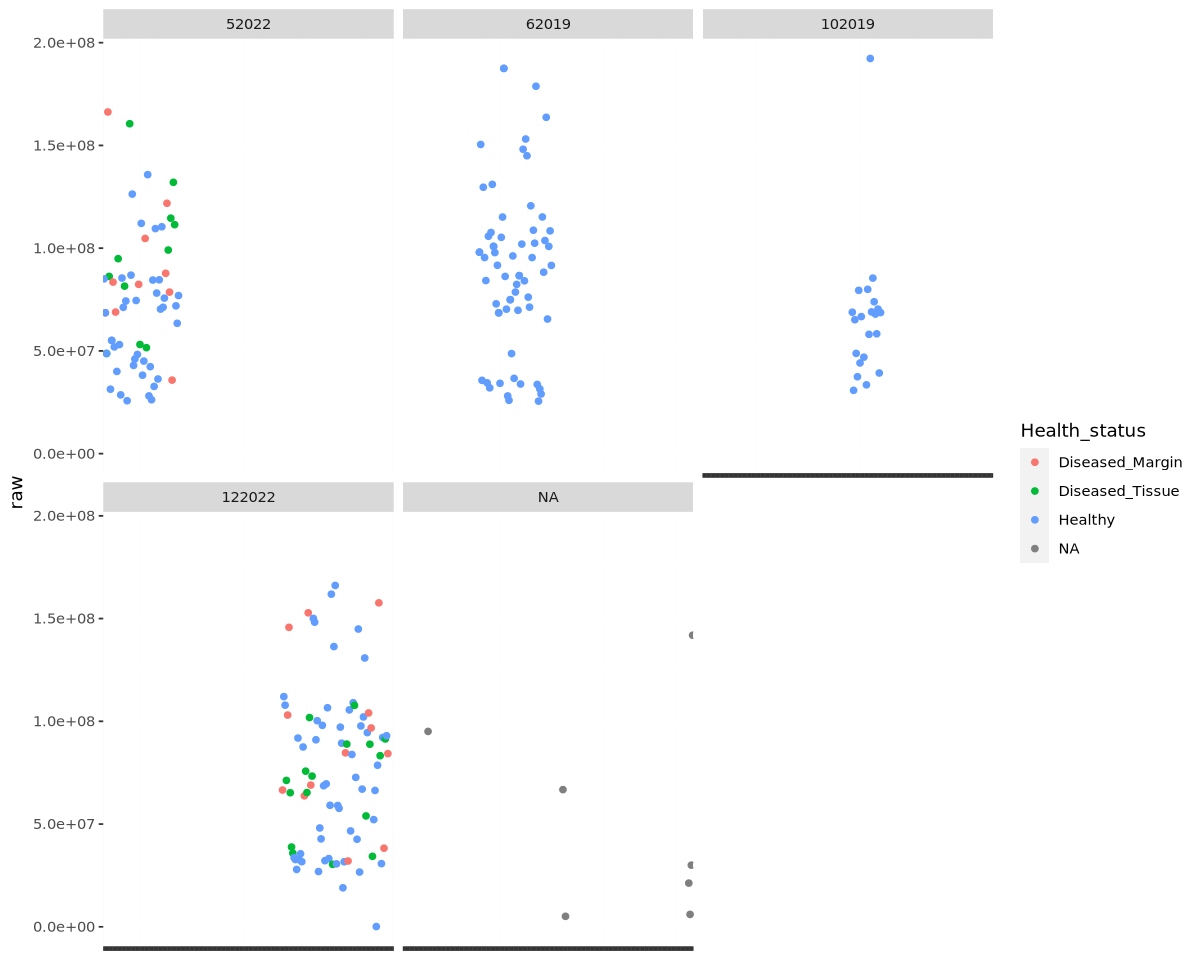

In [20]:
# view num of reads per sample - identify outliers 
ggplot(reads_combined, aes(x=sampleid, y = raw, color = Health_status))+
    geom_point()+
    facet_wrap(~Month_year)+
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank())

In [21]:
# pretty even spread across time points
# lets look at seqs with rly low reads 

In [22]:
head(reads_wide %>% arrange(raw),20)
# definitely not good that some of these are lower than the negatives 
# can look more at these after next step? not sure what to do yet 
# will probably have to get rid of the 120222_t4_3_mcav since it is lowest 

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [23]:
# how can i find like samples with the lowest 10% of read coverage 
summary(reads_wide)

   sampleid              raw               trimmed            pct_yield    
 Length:226         Min.   :   120943   Min.   :   120525   Min.   :98.25  
 Class :character   1st Qu.: 45291641   1st Qu.: 45459415   1st Qu.:99.72  
 Mode  :character   Median : 74727471   Median : 74764042   Median :99.78  
                    Mean   : 77443169   Mean   : 77335407   Mean   :99.75  
                    3rd Qu.: 99991119   3rd Qu.: 99357026   3rd Qu.:99.83  
                    Max.   :192301811   Max.   :191938002   Max.   :99.88  
                                        NA's   :3           NA's   :3      

In [24]:
# maybe look at everything lower than the first quartile?
reads_wide %>%
    filter(raw < 45291641) %>% 
    arrange(raw)
# 57 samples lower than first quartile

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [25]:
low <- quantile(reads_wide$raw, probs = 0.10)

low_samples <- reads_wide %>%
  filter(raw < low) %>%
  arrange(raw)

low_samples

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [26]:
# set thresholds - see how many samples fall into each?
# need to read to determine what the thresholds should be 
reads_wide <- reads_wide %>%
  mutate(qc_status = case_when(
      raw < 1e6 ~ "Fail (<1M)",
      raw < 1e7 ~ "Low (1M-10M)",
      TRUE ~ "Pass (>10M)"
  ))

In [27]:
reads_wide %>%
    group_by(qc_status) %>%
    summarise(n = n())

qc_status,n
<chr>,<int>
Fail (<1M),1
Low (1M-10M),2
Pass (>10M),223


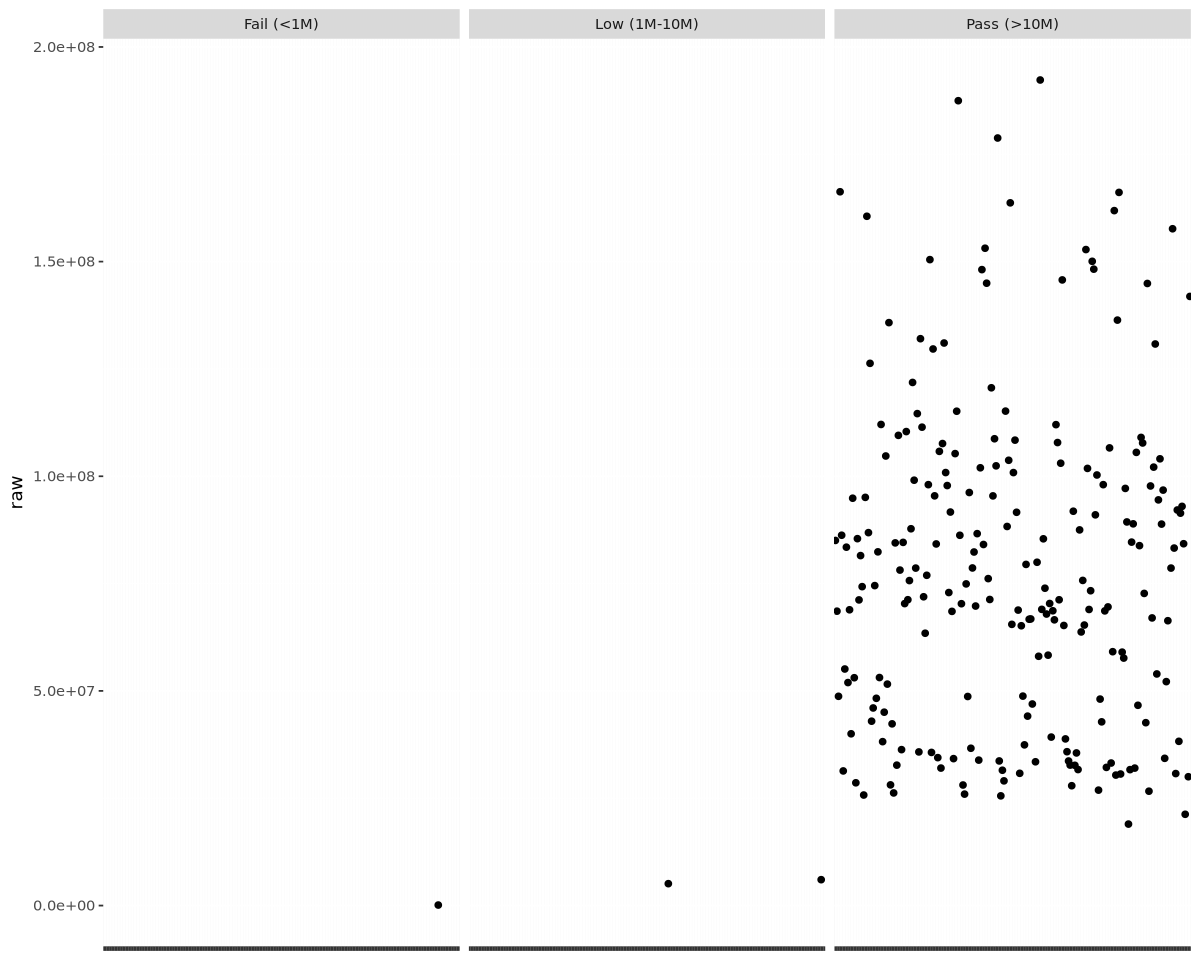

In [28]:
# view num of reads per sample - identify outliers 
ggplot(reads_wide, aes(x=sampleid, y = raw))+
    geom_point()+
    facet_wrap(~qc_status)+
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank())

In [29]:
reads_wide %>%
    filter(!(qc_status == "Pass (>10M)"))

sampleid,raw,trimmed,pct_yield,qc_status
<chr>,<int>,<int>,<dbl>,<chr>
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA,Low (1M-10M)
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65,Fail (<1M)
7_3_Neg,6030707,5925379,98.25,Low (1M-10M)


In [30]:
# can deffs filter these out for now and then decide about the rest??
# just filtering out hosts and this 1 sample, going to assemble negatives together

In [31]:
reads_filtered<-reads_wide$sampleid[names(reads_wide$sampleid) %in% c('102019_BEL_CBC_T2_31_PSTR_host','102019_BEL_CBC_T2_30_PSTR_host','122022_BEL_CBC_T4_3_MCAV')]

In [32]:
reads_filtered

character(0)

In [33]:
filtered_samples<-reads_wide$sampleid[!(reads_wide$sampleid %in% c('102019_BEL_CBC_T2_31_PSTR_host','102019_BEL_CBC_T2_30_PSTR_host',
                                                 '122022_BEL_CBC_T4_3_MCAV',"Undetermined"))]

In [34]:
# idk why cant fix oann rn so going to add data manually for now 
samplefix<-data.frame('sampleid' = '052022_BEL_CBC_T1_63_OANN','Month_year' = 52022, 'Transect' = 'CBC30N', 'TransectNum' = 1, 'NewTagNum' = '25', 
           'Species' = 'OANN', 'SampleNum' = '63', 'Health_status' = 'Healthy', 'colony_id' = 'T1_25_OANN')
reads_combined<-reads_combined %>%
    rows_update(samplefix, by = "sampleid")

In [35]:
reads_combined<-reads_combined %>%
# add metadata for negatives
    mutate(group = if_else(grepl("Neg",sampleid), "Negative", paste0(Month_year, "_", Species, "_", Health_status))) %>%
# and combine orbis
    mutate(Species = case_when(grepl("Neg",sampleid) ~"NEG",
                               Species == "OFAV" ~ "ORBI",
                               Species == "OANN" ~ "ORBI",
                               TRUE ~ Species))

In [36]:
# investigate NAs 
reads_combined %>%
    filter(grepl("NA",group))

sampleid,raw,trimmed,pct_yield,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,Sampling_notes,colony_id,group
<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
102019_BEL_CBC_T2_30_PSTR_host,66763853,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA
Undetermined,141888465,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA


In [37]:
# this is supposed to be an oann : 052022_BEL_CBC_T1_63_OFAV - will change sample name and everything from here but leaving raw files alone 
# 122022_BEL_CBC_T4_1_OFAV was misnumbered as #4 (found raw datasheet and corrected in sctld_samples)
# 122022_BEL_CBC_T4_8_PSTR was misnumbered as #3 (found raw datasheet and corrected in sctld_samples)

# reuploading metadata to fix these


In [38]:
unique(reads_combined$group)

[1] "52022_PSTR_Diseased_Margin"  "52022_PSTR_Healthy"         
 [3] "52022_PSTR_Diseased_Tissue"  "52022_MCAV_Diseased_Margin" 
 [5] "52022_MCAV_Diseased_Tissue"  "52022_PAST_Healthy"         
 [7] "52022_OANN_Healthy"          "52022_PAST_Diseased_Tissue" 
 [9] "52022_MCAV_Healthy"          "52022_OFAV_Healthy"         
[11] "52022_PAST_Diseased_Margin"  "62019_MMEA_Healthy"         
[13] "62019_PAST_Healthy"          "62019_MCAV_Healthy"         
[15] "102019_PSTR_Healthy"         "NA_NA_NA"                   
[17] "122022_OANN_Diseased_Margin" "122022_PSTR_Healthy"        
[19] "122022_OANN_Healthy"         "122022_PSTR_Diseased_Tissue"
[21] "122022_PSTR_Diseased_Margin" "122022_PAST_Diseased_Margin"
[23] "122022_OANN_Diseased_Tissue" "122022_PAST_Diseased_Tissue"
[25] "122022_MCAV_Diseased_Tissue" "122022_PAST_Healthy"        
[27] "122022_MCAV_Healthy"         "122022_OFAV_Diseased_Margin"
[29] "122022_OFAV_Diseased_Tissue" "122022_OFAV_Healthy"        
[31] "122022_MCAV_Diseased_Margin" "Negative"

In [39]:
reads_combined<-reads_combined %>% filter(sampleid %in% filtered_samples) %>% select (-Sampling_notes)

In [45]:
# add group and spp to filtered sample list 
head(filtered_samples)
filtered_sample_group<-reads_combined %>%
    select(sampleid,Species,group) %>%
    rename(specie = Species)
tail(filtered_sample_group)

[1] "052022_BEL_CBC_T1_10_PSTR" "052022_BEL_CBC_T1_11_PSTR"
[3] "052022_BEL_CBC_T1_12_MCAV" "052022_BEL_CBC_T1_13_MCAV"
[5] "052022_BEL_CBC_T1_1_PAST"  "052022_BEL_CBC_T1_34_PAST"

sampleid,specie,group
<chr>,<chr>,<chr>
122022_BEL_CBC_T4_6_MCAV,MCAV,122022_MCAV_Diseased_Tissue
122022_BEL_CBC_T4_8_PSTR,PSTR,122022_PSTR_Healthy
122022_BEL_CBC_T4_9_OFAV,ORBI,122022_OFAV_Diseased_Margin
7_11_Neg,NEG,Negative
7_3_Neg,NEG,Negative
Negative_extract_11-2-24,NEG,Negative


In [46]:
write.table(filtered_sample_group, 'filtered_sample_groups.txt', row.names = FALSE, quote = FALSE, sep = '\t')
write.csv(reads_combined, "reads_meta.csv", row.names = FALSE, quote = FALSE)

In [168]:
# need to create appendix for all of these freakin files i created

## Assembly Steps

In [ ]:
# have to switch to python cuz i already wrote this code in python and I dont want to redo it

In [1]:
import os
import gzip
# from Bio import SeqIO
import pandas as pd
import re
import numpy as np

In [2]:
# set dir
os.chdir('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/')

In [3]:
ls

CBC_ColonyData.csv  NEG/   filtered_sample_groups.txt  reads_meta.csv
CBC_samples.csv     ORBI/  filtered_samples.txt        sampleids.txt
MCAV/               PAST/  reads.csv
MMEA/               PSTR/  reads_filtered


### Host Removal

In [ ]:
# in process of redoing read count estimations from single specie scripts below - to using multiqc

In [ ]:
#!/bin/bash
#SBATCH -c 24  # Number of Cores per Task
#SBATCH --mem=50G  # Requested Memory
#SBATCH -p cpu  # Partition
#SBATCH -t 48:00:00  # Job time limit
#SBATCH --mail-type=ALL
#SBATCH -o /work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/slurm-multiqc-%j.out  # %j = job ID

# run multiqc in both host removal and symbiont steps to calculate read count..
# get unique species from list of samples, spp, and groups

module load conda/latest
conda activate qc

slurm_dir="/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs"
base_dir="/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw"
cd $base_dir

dir_list=$(ls -d */)
for dir in $dir_list; do 
    spp=${dir%/}
    echo "fastqc host_removed spp: ${spp}"
    fastqc ${spp}/assembly/host_removed/*.fastq* --threads 16
    echo "fastqc final_filtered spp: ${spp}"
    fastqc ${spp}/assembly/final_filtered/*_ready.fastq* --threads 16

    echo "multiqc spp: ${spp}"
    multiqc $base_dir/$spp/. $slurm_dir/$spp/. \
            -n "${spp}_QC_Report" \
            --outdir "${base_dir}/${spp}/assembly/qc_reports"
done

conda deactivate

# job id: 56139675, 56233305

In [ ]:
# to get negative:
# fastqc ran, only multiqc failed - so just need to direct it to all fastqc results
# run in terminal

# module load conda/latest
# conda activate multiqc
# slurm_dir="/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs"
# base_dir="/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw"

# spp="NEG"
# multiqc $base_dir/$spp/. $slurm_dir/$spp/. \
#     -n "${spp}_QC_Report" \
#     --outdir "${base_dir}/${spp}/assembly/qc_reports"

In [ ]:
# upload all multiqc reports and compile

In [4]:
from pathlib import Path

In [19]:
pattern = "*/assembly/qc_reports/*_QC_Report_data/multiqc_fastqc.txt"
# search current directory for paths patching the pattern 
files = list(Path('.').glob(pattern))
    # need to add NEG in here somehow?

# import all into single df
df_list = [pd.read_csv(f, sep='\t') for f in files]
fastqc_df = pd.concat(df_list, ignore_index=True)

In [20]:
fastqc_df.head(3)

,Sample,Filename,File type,Encoding,Total Sequences,Total Bases,Sequences flagged as poor quality,Sequence length,%GC,total_deduplicated_percentage,...,per_base_sequence_quality,per_tile_sequence_quality,per_sequence_quality_scores,per_base_sequence_content,per_sequence_gc_content,per_base_n_content,sequence_length_distribution,sequence_duplication_levels,overrepresented_sequences,adapter_content
0,052022_BEL_CBC_T1_35_OANN_host_removed_R1,052022_BEL_CBC_T1_35_OANN_host_removed_R1.fast...,Conventional base calls,Sanger / Illumina 1.9,20263133.0,2.2 Gbp,0.0,20-151,44.0,82.762547,...,pass,fail,pass,fail,pass,pass,warn,pass,pass,pass
1,052022_BEL_CBC_T1_35_OANN_host_removed_R1.tagg...,052022_BEL_CBC_T1_35_OANN_host_removed_R1.tagg...,Conventional base calls,Sanger / Illumina 1.9,11567080.0,1.2 Gbp,0.0,20-151,40.0,81.688255,...,pass,fail,pass,fail,pass,pass,warn,pass,pass,pass
2,052022_BEL_CBC_T1_35_OANN_host_removed_R2,052022_BEL_CBC_T1_35_OANN_host_removed_R2.fast...,Conventional base calls,Sanger / Illumina 1.9,20263133.0,2.2 Gbp,0.0,20-151,44.0,82.842516,...,pass,fail,pass,fail,pass,pass,warn,pass,warn,pass


In [22]:
# repeat for genome alignments

pattern = "*/assembly/qc_reports/*_QC_Report_data/multiqc_fastq_screen.txt"
# search current directory for paths patching the pattern 
files = list(Path('.').glob(pattern))
    # need to add NEG in here somehow?

# import all into single df
df_list = [pd.read_csv(f, sep='\t') for f in files]
multiqc_df = pd.concat(df_list, ignore_index=True)
multiqc_df.head(3)

,Sample,total_reads,Human counts,Human percentage,Symbiont1 counts,Symbiont1 percentage,Symbiont2 counts,Symbiont2 percentage,Symbiont3 counts,Symbiont3 percentage,...,Symbiont8 counts,Symbiont8 percentage,Symbiont9 counts,Symbiont9 percentage,Symbiont10 counts,Symbiont10 percentage,Symbiont11 counts,Symbiont11 percentage,No hits counts,No hits percentage
0,052022_BEL_CBC_T1_35_OANN_host_removed_R1_screen,20263133,391362.0,1.93,511515.0,2.52,610476.0,3.02,2056638.0,10.15,...,587502.0,2.89,621394.0,3.06,1156392.0,5.70,2282113.0,11.27,11829617,58.38
1,052022_BEL_CBC_T1_35_OANN_host_removed_R2_screen,20263133,427477.0,2.11,565874.0,2.79,664377.0,3.28,2096339.0,10.35,...,644221.0,3.18,677322.0,3.34,1210016.0,5.96,2318793.0,11.44,11825564,58.36
2,052022_BEL_CBC_T1_41_OANN_host_removed_R1_screen,11347352,219522.0,1.93,491968.0,4.34,272184.0,2.40,600734.0,5.29,...,264312.0,2.34,282369.0,2.49,403722.0,3.55,674763.0,5.94,8906536,78.49
